In [12]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
from typing import Dict, List, Any
from transformers import AutoTokenizer, CLIPImageProcessor
from torch.amp import autocast, GradScaler
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
import math
from pprint import pprint
import random

In [2]:
!ls /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017

annotations  test2017  train2017  val2017


In [3]:
!ls /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations

captions_train2017.json   instances_val2017.json
captions_val2017.json	  person_keypoints_train2017.json
instances_train2017.json  person_keypoints_val2017.json


In [4]:
annotations_json_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json"

In [5]:
with open(annotations_json_path, 'r', encoding='utf-8') as f:
    annotations = json.load(f)

In [6]:
print(annotations.keys())
pprint(annotations["images"][1])
target_id = annotations["images"][1]['id']
for i in range(len(annotations['annotations'])):
    if annotations['annotations'][i]['image_id'] == target_id:
        pprint(annotations["annotations"][i])
        print()
        pprint(annotations['images'][i])
        print("-"*50)

dict_keys(['info', 'licenses', 'images', 'annotations'])
{'coco_url': 'http://images.cocodataset.org/train2017/000000522418.jpg',
 'date_captured': '2013-11-14 11:38:44',
 'file_name': '000000522418.jpg',
 'flickr_url': 'http://farm1.staticflickr.com/1/127244861_ab0c0381e7_z.jpg',
 'height': 480,
 'id': 522418,
 'license': 4,
 'width': 640}
{'caption': 'A woman wearing a net on her head cutting a cake. ',
 'id': 681330,
 'image_id': 522418}

{'coco_url': 'http://images.cocodataset.org/train2017/000000257382.jpg',
 'date_captured': '2013-11-16 17:08:14',
 'file_name': '000000257382.jpg',
 'flickr_url': 'http://farm9.staticflickr.com/8264/8684815450_84c88a94d4_z.jpg',
 'height': 426,
 'id': 257382,
 'license': 1,
 'width': 640}
--------------------------------------------------
{'caption': 'A woman cutting a large white sheet cake.',
 'id': 686718,
 'image_id': 522418}

{'coco_url': 'http://images.cocodataset.org/train2017/000000434192.jpg',
 'date_captured': '2013-11-18 01:17:27',
 'fil

In [7]:
bbox_json_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"

In [8]:
with open(bbox_json_path, 'r', encoding='utf-8') as f:
    bboxes = json.load(f)

In [9]:
print(bboxes.keys())
for i in range(len(bboxes['annotations'])):
    if bboxes['annotations'][i]['image_id'] == target_id:
        pprint(bboxes["annotations"][i])
        break

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
{'area': 63325.421899999994,
 'bbox': [382.48, 0.0, 256.8, 474.31],
 'category_id': 1,
 'id': 455475,
 'image_id': 522418,
 'iscrowd': 0,
 'segmentation': [[426.91,
                   58.24,
                   434.49,
                   77.74,
                   467.0,
                   80.99,
                   485.42,
                   86.41,
                   493.0,
                   129.75,
                   521.17,
                   128.67,
                   532.01,
                   144.92,
                   545.01,
                   164.42,
                   552.6,
                   170.93,
                   588.35,
                   178.51,
                   629.53,
                   165.51,
                   629.53,
                   177.43,
                   578.6,
                   214.27,
                   558.01,
                   241.35,
                   526.59,
                

In [10]:
cats = [bboxes["categories"][i]['name'] for i in range(len(bboxes["categories"]))]
len(cats), cats

(80,
 ['person',
  'bicycle',
  'car',
  'motorcycle',
  'airplane',
  'bus',
  'train',
  'truck',
  'boat',
  'traffic light',
  'fire hydrant',
  'stop sign',
  'parking meter',
  'bench',
  'bird',
  'cat',
  'dog',
  'horse',
  'sheep',
  'cow',
  'elephant',
  'bear',
  'zebra',
  'giraffe',
  'backpack',
  'umbrella',
  'handbag',
  'tie',
  'suitcase',
  'frisbee',
  'skis',
  'snowboard',
  'sports ball',
  'kite',
  'baseball bat',
  'baseball glove',
  'skateboard',
  'surfboard',
  'tennis racket',
  'bottle',
  'wine glass',
  'cup',
  'fork',
  'knife',
  'spoon',
  'bowl',
  'banana',
  'apple',
  'sandwich',
  'orange',
  'broccoli',
  'carrot',
  'hot dog',
  'pizza',
  'donut',
  'cake',
  'chair',
  'couch',
  'potted plant',
  'bed',
  'dining table',
  'toilet',
  'tv',
  'laptop',
  'mouse',
  'remote',
  'keyboard',
  'cell phone',
  'microwave',
  'oven',
  'toaster',
  'sink',
  'refrigerator',
  'book',
  'clock',
  'vase',
  'scissors',
  'teddy bear',
  'hai

In [ ]:
class LlavaDataset(Dataset):
    def __init__(self, capt_json_path, inst_json_path, img_dir, tokenizer, image_processor, max_length):#
        super().__init__()

        print("json process")
        with open(capt_json_path, 'r', encoding='utf-8') as f:
            self.annotations = json.load(f)
        with open(inst_json_path, 'r', encoding='utf-8') as f:
            self.instance = json.load(f)

        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.max_length = max_length

        self.img_id_to_img = {img['id']:img for img in self.annotations['images']}
        self.cat_id_to_cat = {cat['id']:cat for cat in self.instance['categories']}
        self.img_id_to_captions = {}
        for ann in self.annotations['annotations']:
            self.img_id_to_captions.setdefault(ann['image_id'], []).append(ann['caption'])

        self.IMAGE_TOKEN = "<img>"

        self.samples = []

        print("caption part process")
        for ann in self.annotations['annotations']:
            img_id = ann['image_id']
            self.samples.append({
                "task_type":"caption",
                "image_id":img_id,
                "caption":ann['caption']
            })
        
        print("grounding part process")
        for inst in self.instance['annotations']:
            img_id = inst['image_id']
            cat = self.cat_id_to_cat[inst["category_id"]]["name"]
            self.samples.append({
                "task_type":"grounding",
                "image_id":img_id,
                "object_name":cat,
                "bbox":inst["bbox"]
            })
        random.shuffle(self.samples)

        print("joint part process")
        for inst in self.instance['annotations']:
            if random.random() < 0.3:
                img_id = inst['image_id']
                if img_id in self.img_id_to_captions:
                    cat = self.cat_id_to_cat[inst["category_id"]]["name"]
                    caption_random = random.choice(self.img_id_to_captions[img_id])
                    
                    self.samples.append({
                        "task_type": "joint",
                        "image_id": img_id,
                        "caption": caption_random,
                        "object_name": cat,
                        "bbox": inst["bbox"]
                    })

                    self.samples.append({
                        "task_type": "locate_and_describe",
                        "image_id": img_id,
                        "caption": caption_random,
                        "object_name": cat,
                        "bbox": inst["bbox"]
                    })

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        sample = self.samples[index]
        image_data = self.img_id_to_img[sample['image_id']]
        image_path = os.path.join(self.img_dir, image_data['file_name'])
        image = Image.open(image_path).convert("RGB")

        image_tensor = self.image_processor(image, return_tensors="pt")["pixel_values"].squeeze(0)

        if sample['task_type'] == "caption":
            caption = sample['caption']
            prompt_user = f"<|im_start|>user\n{self.IMAGE_TOKEN}\nDescribe this image.<|im_end|>\n"
            full_text = f"{prompt_user}<|im_start|>assistant\n{caption}<|im_end|>"
            prompt_tokens = self.tokenizer(prompt_user, allowed_special='all')['input_ids']
            full_tokens =  self.tokenizer(full_text, allowed_special='all')['input_ids']

            input_ids = torch.tensor(full_tokens, dtype=torch.long)
            labels = input_ids.clone()
            labels[:len(prompt_tokens)] = -100

            return {
                "input_ids":input_ids,
                "labels":labels,
                "image_tensor":image_tensor,
                "image_path":image_path,
                "caption":caption,
                "bboxes": torch.tensor([-1.0, -1.0, -1.0, -1.0], dtype=torch.float32)
            }
        
        elif sample['task_type'] == 'grounding':
            object_name = sample['object_name']
            prompt_user = f"<|im_start|>user\n{self.IMAGE_TOKEN}\nLocate the {object_name}.<|im_end|>\n"

            img_w, img_h = image_data['width'], image_data['height']
            x, y, w, h = sample['bbox']

            x1, y1, x2, y2 = x, y, x+w, y+h
            x1 = x1 / img_w
            y1 = y1 / img_h
            x2 = x2 / img_w
            y2 = y2 / img_h

            full_text = f"{prompt_user}<|im_start|>assistant\n<loc><|im_end|>"

            prompt_tokens = self.tokenizer(prompt_user, allowed_special='all')['input_ids']
            full_tokens =  self.tokenizer(full_text, allowed_special='all')['input_ids']

            input_ids = torch.tensor(full_tokens, dtype=torch.long)
            labels = input_ids.clone()
            labels[:len(prompt_tokens)] = -100

            return {
                "input_ids":input_ids,
                "labels":labels,
                "image_tensor":image_tensor,
                "image_path":image_path,
                "caption": "",
                "bboxes": torch.tensor([x1, y1, x2, y2], dtype=torch.float32) 
            }
        
        elif sample['task_type'] == 'joint':
            caption = sample['caption']
            object_name = sample['object_name']

            img_w, img_h = image_data['width'], image_data['height']
            x, y, w, h = sample['bbox']

            x1, y1, x2, y2 = x, y, x+w, y+h
            x1 = x1 / img_w
            y1 = y1 / img_h
            x2 = x2 / img_w
            y2 = y2 / img_h

            prompt_user_1 = f"<|im_start|>user\n{self.IMAGE_TOKEN}\nDescribe this image.<|im_end|>\n"
            answer_1 = f"<|im_start|>assistant\n{caption}<|im_end|>\n"
            
            prompt_user_2 = f"<|im_start|>user\nLocate the {object_name}.<|im_end|>\n"
            answer_2 = f"<|im_start|>assistant\n<loc><|im_end|>"

            t_user1 = self.tokenizer(prompt_user_1, allowed_special='all')['input_ids']
            t_ans1 = self.tokenizer(answer_1, allowed_special='all')['input_ids']
            t_user2 = self.tokenizer(prompt_user_2, allowed_special='all')['input_ids']
            t_ans2 = self.tokenizer(answer_2, allowed_special='all')['input_ids']

            input_ids = t_user1 + t_ans1 + t_user2 + t_ans2
            input_ids = torch.tensor(input_ids, dtype=torch.long)

            labels = input_ids.clone()
            labels[:len(t_user1)] = -100
            labels[len(t_user1)+len(t_ans1) : len(t_user1)+len(t_ans1)+len(t_user2)] = -100

            return {
                "input_ids":input_ids,
                "labels":labels,
                "image_tensor":image_tensor,
                "image_path":image_path,
                "caption":caption,
                "bboxes": torch.tensor([x1, y1, x2, y2], dtype=torch.float32) 
            }
        
        elif sample['task_type'] == 'locate_and_describe':
            caption = sample['caption']
            object_name = sample['object_name']

            img_w, img_h = image_data['width'], image_data['height']
            x, y, w, h = sample['bbox']

            x1, y1, x2, y2 = x, y, x+w, y+h
            x1 = x1 / img_w
            y1 = y1 / img_h
            x2 = x2 / img_w
            y2 = y2 / img_h

            prompt_user = f"<|im_start|>user\n{self.IMAGE_TOKEN}\nDescribe this image and locate the {object_name}.<|im_end|>\n"
            answer = f"<|im_start|>assistant\n{caption} The {object_name} is located here: <loc><|im_end|>"

            full_text = prompt_user+answer
            prompt_tokens = self.tokenizer(prompt_user, allowed_special='all')['input_ids']
            full_tokens =  self.tokenizer(full_text, allowed_special='all')['input_ids']

            input_ids = torch.tensor(full_tokens, dtype=torch.long)

            labels = input_ids.clone()
            labels[:len(prompt_tokens)] = -100

            return {
                "input_ids": input_ids,
                "labels": labels,
                "image_tensor": image_tensor,
                "image_path": image_path, 
                "caption": caption,           
                "bboxes": torch.tensor([x1, y1, x2, y2], dtype=torch.float32) 
            }



<>:104: SyntaxWarning: invalid escape sequence '\L'
<>:104: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_84/1874060205.py:104: SyntaxWarning: invalid escape sequence '\L'
  prompt_user = f"<|im_start|>user\n{self.IMAGE_TOKEN}\Locate the {object_name}.<|im_end|>\n"


In [17]:
class LLaVADataCollator: 
    def __init__(self, pad_token_id):
        self.pad_token_id = pad_token_id

    def __call__(self, batch):
        input_ids = [item["input_ids"] for item in batch]
        labels = [item["labels"] for item in batch]
        images = [item["image_tensor"] for item in batch]
        bboxes = [item["bboxes"] for item in batch] # <- достаем из датасета

        input_ids_pad = pad_sequence(sequences=input_ids, batch_first=True, padding_value=self.pad_token_id)
        labels_padded = pad_sequence(labels, batch_first=True, padding_value=-100)
        images_stack = torch.stack(images)
        bboxes_stack = torch.stack(bboxes)

        return {
            "input_ids": input_ids_pad,
            "labels": labels_padded,
            "image_tensor": images_stack,
            "bboxes": bboxes_stack    
        }

In [18]:
llm_name = "Qwen/Qwen2.5-0.5B-Instruct"
vision_model_name = "openai/clip-vit-large-patch14-336"

tokenizer = AutoTokenizer.from_pretrained(llm_name) #Qwen/Qwen2.5-1.5B-Instruct
special_tokens_to_add = ["<img>", "<loc>"]
tokenizer.add_tokens(special_tokens_to_add, special_tokens=True)

image_processor = CLIPImageProcessor.from_pretrained(vision_model_name)  #openai/clip-vit-base-patch16

INSTANCES_JSON = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"
CAPTIONS_JSON = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json"
IMAGES_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"

dataset = LlavaDataset(
    capt_json_path=CAPTIONS_JSON,
    inst_json_path=INSTANCES_JSON,
    img_dir=IMAGES_DIR,
    tokenizer=tokenizer,
    image_processor=image_processor,
    max_length=256 
)

json process
caption part process
grounding part process
joint part process


In [19]:
dataset[0]

{'input_ids': tensor([151644,    872,    198, 151665,    198,  74785,    419,   2168,     13,
         151645,    198, 151644,  77091,    198,  11613,  13876,  29724,   4227,
           1526,   1045,  14035,    392,  30204,    323,  12408,     13, 151645]),
 'labels': tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100, 151644,  77091,    198,  11613,  13876,  29724,   4227,
           1526,   1045,  14035,    392,  30204,    323,  12408,     13, 151645]),
 'image_tensor': tensor([[[ 1.6530,  1.6676,  1.6530,  ..., -1.0185, -0.8142, -0.4054],
          [ 1.6676,  1.6676,  1.6530,  ..., -1.1061, -0.9018, -0.7850],
          [ 1.6530,  1.6676,  1.6530,  ..., -1.1061, -1.1207, -0.8142],
          ...,
          [-0.5368, -0.6244, -0.1426,  ..., -0.0550, -0.0842, -0.1134],
          [-0.4200, -0.2740, -0.1718,  ..., -0.0988, -0.1134, -0.0988],
          [-0.9893, -0.7266, -0.2740,  ..., -0.2740, -0.1426, -0.0696]],
 
         [[ 1.8498,  

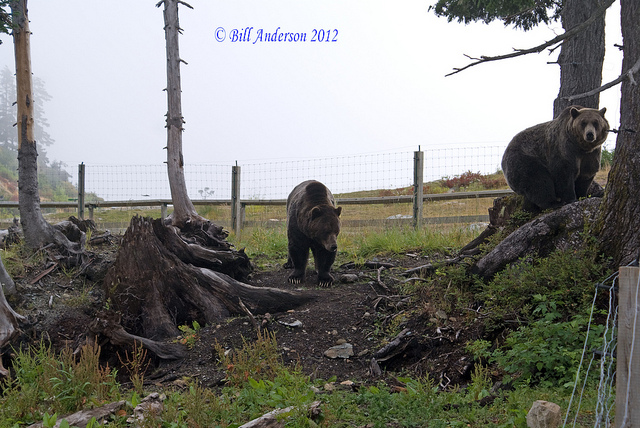

Two brown bears walk through some shrubbery and trees.


(tensor([151644,    872,    198, 151665,    198,  74785,    419,   2168,     13,
         151645,    198, 151644,  77091,    198,  11613,  13876,  29724,   4227,
           1526,   1045,  14035,    392,  30204,    323,  12408,     13, 151645]),
 tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100, 151644,  77091,    198,  11613,  13876,  29724,   4227,
           1526,   1045,  14035,    392,  30204,    323,  12408,     13, 151645]),
 tensor([1.6530, 1.6676]))

In [20]:
from IPython.display import display
sample = dataset[0]

img = Image.open(sample["image_path"]).convert("RGB")
display(img)
print(sample['caption'])
sample['input_ids'], sample['labels'], sample['image_tensor'][0][0][:2]

In [30]:
class LLaVAMLP(torch.nn.Module):
    def __init__(self, vision_dim, text_dim, downscale_factor=2):
        super().__init__()
        self.downscale_factor = downscale_factor
        self.linear_1 = torch.nn.Linear(vision_dim * (downscale_factor**2), text_dim, bias=True)
        self.act = torch.nn.GELU()
        self.linear_2 = torch.nn.Linear(text_dim, text_dim, bias=True)

    def unshuffle(self, image_fetures, downscale_factor):
        B, L, D = image_fetures.shape #batch, seq_len, dimension
        H = int(math.sqrt(L))
        W = H
        assert H * W == L 

        x = image_fetures.view(B, H, W, D).permute(0, 3, 1, 2) #dim must be second fr pt
        x = torch.nn.functional.pixel_unshuffle(x, downscale_factor)

        B, new_C, new_H, new_W = x.shape
        x = x.view(B, new_C, new_H*new_W).permute(0, 2, 1)
        return x


    def forward(self, image_features):
        x = self.unshuffle(image_features, self.downscale_factor)
        return self.linear_2(self.act(self.linear_1(x)))
        #return self.linear_2(self.act(self.linear_1(image_features)))

In [ ]:
class DetectionHead(torch.nn.Module):
    def __init__(self, emb_dim, hidden_size = 512):
        super().__init__()
        self.emb_dim = emb_dim
        self.hidden_size = hidden_size
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(emb_dim, self.hidden_size, bias=True),
            torch.nn.LayerNorm(self.hidden_size),
            torch.nn.GELU(),

            torch.nn.Linear(self.hidden_size, self.hidden_size, bias=True),
            torch.nn.LayerNorm(self.hidden_size),
            torch.nn.GELU(),

            torch.nn.Linear(self.hidden_size, 4),
            torch.nn.Sigmoid()
        )
    
    def forward(self, iloc_emb):
        return self.mlp(iloc_emb)

In [ ]:
class LLaVA(torch.nn.Module):
    def __init__(self, vision_module, llm_module, mlp_module, head_module):
        super().__init__()
        self.vision_module = vision_module
        self.llm_module = llm_module
        self.mlp_module = mlp_module
        self.head_module = head_module

        self.IMAGE_TOKEN_ID = None
        self.LOC_TOKEN_ID = None

    def forward(self, input_ids, image_tensor, labels, bboxes=None):
        text_embs = self.llm_module.model.embed_tokens(input_ids)

        with torch.no_grad():
            image_out = self.vision_module(image_tensor, output_hidden_states=True)
            # image_features = image_out.last_hidden_state[-2][:, 1:] 
            image_features = image_out.hidden_states[-2][:, 1:] # from article, last hidden state its better then last state, cause last state focus on [cls] token in general


        image_embs = self.mlp_module(image_features) #[b, num_putch, hid_state]

        B, seq_len = input_ids.shape
        num_patches = image_embs.shape[1] #[b, num putches, hid_state]
        final_len = seq_len - 1 + num_patches # -1 cause replace <img> token on img describe embs
        D = text_embs.shape[-1]


        image_positions = (input_ids == self.IMAGE_TOKEN_ID).nonzero(as_tuple=True)[1]

        model_grid = torch.arange(final_len, device=input_ids.device).unsqueeze(0).repeat(B, 1)
        src_grid = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).repeat(B, 1)

        image_start_pos = image_positions.unsqueeze(1)
        image_end_pos = image_start_pos + num_patches

        is_img_dst = (image_start_pos <= model_grid) & (model_grid < image_end_pos)
        txt_before_dst = model_grid < image_start_pos # begore img part
        txt_after_dst = image_end_pos <= model_grid # after img part

        txt_before_src = src_grid < image_start_pos #before <img> token
        txt_after_src = src_grid > image_start_pos #after <img> token

        final_embs = torch.zeros(B, final_len, D, dtype=text_embs.dtype, device=text_embs.device)
        final_labels = torch.full((B, final_len), -100, dtype=labels.dtype, device=labels.device)

        final_embs[is_img_dst] = image_embs.to(final_embs.dtype).view(-1, D)
        final_embs[txt_before_dst] = text_embs[txt_before_src]
        final_embs[txt_after_dst] = text_embs[txt_after_src]

        final_labels[txt_before_dst] = labels[txt_before_src] # cause of all dialog is included in one time, we need to consider in labels part with model answer before 
        # exmp
        # - hello -hello, what can i help -whats on this pict <img> -on this pict i see a dog
        #   -100    67     52  42  69 18  -100 -100 -100 -100  -100   1.  2.   3. 4. 5. 6. 1
        final_labels[txt_after_dst] = labels[txt_after_src]

        outputs = self.llm_module(
            inputs_embeds=final_embs,
            labels = final_labels,
            return_dict = True,
            use_cache=False,
            output_hidden_states = True
        )

        text_loss = outputs.loss


        #iloc
        final_input_ids = torch.full((B, final_len), -100, dtype=input_ids.dtype, device=labels.device)
        final_input_ids[txt_before_dst] = input_ids[txt_before_src]
        final_input_ids[txt_after_dst] = input_ids[txt_after_src]
        final_input_ids[is_img_dst] = self.IMAGE_TOKEN_ID

        pred_bboxes = None
        detection_loss = torch.tensor(0.0, device=input_ids.device)

        batch_idx, col_idx = (final_input_ids == self.LOC_TOKEN_ID).nonzero(as_tuple=True)
        if len(batch_idx) > 0:
            last_hidden_states = outputs.hidden_states[-1]
            loc_embs = last_hidden_states[batch_idx, col_idx]
            pred_bboxes = self.head_module(loc_embs)

            if bboxes is not None:
                target_bboxes = bboxes[batch_idx]
                bbox_mask = (target_bboxes[:, 0] != -1)
                if bbox_mask.sum() > 0: detection_loss = torch.nn.functional.mse_loss(pred_bboxes[bbox_mask], target_bboxes[bbox_mask])


        delt = 2.0
        loss = text_loss + delt*detection_loss
        
        return {
            "loss": loss, 
            "text_loss": text_loss,
            "detection_loss": detection_loss,
            "pred_bboxes": pred_bboxes,
            "batch_idx": batch_idx
        }

In [ ]:
def train_epoch(
        model, dataloader, optimizer, scheduler, device, 
        gradient_accumulation_steps=4, 
        max_grad_norm=1.0,
        use_bfloat16=True
    ):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    dtype = torch.bfloat16 if use_bfloat16 else torch.float16

    scaler = GradScaler(device='cuda', enabled= not use_bfloat16)

    pbar = tqdm(dataloader, desc="Training")
    for step, batch in enumerate(pbar):
        # for mixed precision (hard operation - float16, high precision operation - float32)
        #    def forward(self, input_ids, image_tensor, labels, bboxes=None):
        with autocast(device_type='cuda', dtype=dtype):
            outputs = model(
                batch["input_ids"].to(device),
                batch["image_tensor"].to(device),
                batch["labels"].to(device),
                batch["bboxes"].to(device)
            )
            loss = outputs["loss"]
            loss = loss/gradient_accumulation_steps

        scaler.scale(loss).backward()
        total_loss += loss.item() * gradient_accumulation_steps
        
        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(dataloader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm) # grad explosion protect

            scaler.step(optimizer)
            scaler.update()
            
            if scheduler is not None: scheduler.step()
            
            optimizer.zero_grad()
        
        pbar.set_postfix({
            "loss": loss.item() * gradient_accumulation_steps,
            "text_l": f"{outputs['text_loss'].item():.3f}",
            "det_l": f"{outputs['detection_loss'].item():.4f}"
        })

    return total_loss/len(dataloader)

In [ ]:
# from transformers import TrainingArguments, Trainer

# training_args = TrainingArguments(
#     output_dir="./llava_checkpoints",
#     learning_rate=2e-5,              
#     per_device_train_batch_size=2,   
#     gradient_accumulation_steps=4,   
    
#     bf16=True,
#     max_grad_norm=1.0,
    
#     logging_steps=10, 
#     num_train_epochs=3,
#     remove_unused_columns=False
# )

# trainer = Trainer(
#     model=model,                            
#     args=training_args,                     
#     train_dataset=my_custom_dataset,        
#     data_collator=my_data_collator,         
# )

# trainer.train()

In [ ]:
from transformers import AutoModelForCausalLM, CLIPVisionModel
from torch.utils.data import DataLoader

def main():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"device is {DEVICE}")
    EPOCHS = 6
    BATCH_SIZE = 16
    GRAD_ACC_STEPS = 2

    VISION_DIM = 768
    TEXT_DIM = 896

    llm_module = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen2.5-0.5B-Instruct", 
        dtype=torch.float16
    )
    llm_module.resize_token_embeddings(len(tokenizer))
    llm_module.gradient_checkpointing_enable()

    vision_module = CLIPVisionModel.from_pretrained(
        "openai/clip-vit-base-patch16", 
        dtype=torch.float16
    )

    mlp_module = LLaVAMLP(vision_dim=VISION_DIM, text_dim=TEXT_DIM)
    mlp_ckpt_path = "checkpoints/llava_mlp_epoch_1.pth"
    state = torch.load(mlp_ckpt_path, map_location="cuda" if torch.cuda.is_available() else "cpu")
    mlp_module.load_state_dict(state)

    head_module = DetectionHead(emb_dim=TEXT_DIM)

    model = LLaVA(vision_module, llm_module, mlp_module, head_module)

    model.IMAGE_TOKEN_ID = tokenizer.convert_tokens_to_ids("<img>")
    model.LOC_TOKEN_ID = tokenizer.convert_tokens_to_ids("<loc>")
    model.to(DEVICE)

    for param in model.vision_module.parameters():
        param.requires_grad = False

    # for param in model.llm_module.parameters():
    #     param.requires_grad = False

    for param in model.mlp_module.parameters():
        param.requires_grad = True

    print(f"train params: {sum(par.numel() for par in model.parameters() if par.requires_grad)}")

    collator = LLaVADataCollator(tokenizer.pad_token_id)

    dataloader = DataLoader(
        dataset, BATCH_SIZE, shuffle=True, collate_fn=collator,
        num_workers=2,       
        pin_memory=True,     
        drop_last=True
    )

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3, 
        weight_decay=0.1
    )

    os.makedirs("checkpoints", exist_ok=True)
    loss_log_path = "checkpoints/loss_log.txt"

    for epoch in range(EPOCHS):
        print(f"epoch {epoch+1}/{EPOCHS}")

        loss = train_epoch(
            model, 
            dataloader, 
            optimizer,
            scheduler=None,
            device=DEVICE,
            gradient_accumulation_steps=GRAD_ACC_STEPS,
            use_bfloat16=False
        )
        print(f"loss: {loss}")
        with open(loss_log_path, "a", encoding="utf-8") as f:
            f.write(f"epoch {epoch+1}/{EPOCHS}: {loss}\n")

        torch.save(
            model.mlp_module.state_dict(), 
            f"checkpoints/adapter_epoch_{epoch + 1}.pth"
        )
        torch.save(
            model.llm_module.state_dict(), 
            f"checkpoints/llm_module_epoch_{epoch + 1}.pth"
        )
        torch.save(
            model.head_module.state_dict(), 
            f"checkpoints/head_module_epoch_{epoch + 1}.pth"
        )
        print(f"checkpoint saved")

In [ ]:
main()

Before

epoch 1/3
Training:   0%|          | 55/11743 [00:32<1:56:25,  1.67it/s, loss=2.9] 



After

epoch 1/3
Training:   1%|          | 60/11743 [00:14<45:37,  4.27it/s, loss=3.19]  